In [1]:
import pandas as pd

In [2]:
df = pd.read_pickle("albopictus.pkl")
df = df[df["end_date"] < pd.Timestamp("2021-01-01")]
df = df[df["end_date"] >= pd.Timestamp("2020-01-01")]

In [3]:
# Convert date fields to datetime format
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])

# Display min/max dates to understand data timeframe
print("Minimum start_date:", df["start_date"].min())
print("Maximum start_date:", df["start_date"].max())
print("Minimum end_date:", df["end_date"].min())
print("Maximum end_date:", df["end_date"].max())

# Show date range span in days
print(f"Date range spans {(df['end_date'].max() - df['start_date'].min()).days} days")

Minimum start_date: 2019-12-27 00:00:00
Maximum start_date: 2020-12-30 00:00:00
Minimum end_date: 2020-01-03 00:00:00
Maximum end_date: 2020-12-31 00:00:00
Date range spans 370 days


Date range in dataset:
Start dates: 2019-12-27 00:00:00 to 2020-12-30 00:00:00
End dates: 2020-01-03 00:00:00 to 2020-12-31 00:00:00

Entries with end date before 2020: 0 (0.00%)

Record count by country:
country
Spain              4828
Austria            3519
Albania             912
Greece              827
Switzerland         785
Italy               755
Croatia             724
The Netherlands     453
Serbia              410
Germany             330
Cyprus              295
Turkey              292
Slovenia            246
Portugal            240
Slovakia            140
Moldova             130
France              107
Hungary              86
Luxembourg           80
Morocco              68
Kosovo               51
Romania              28
North Macedonia      21
Name: count, dtype: int64

Occurrence status distribution:
occurrenceStatus
Absent     11710
Present     3617
Name: count, dtype: int64


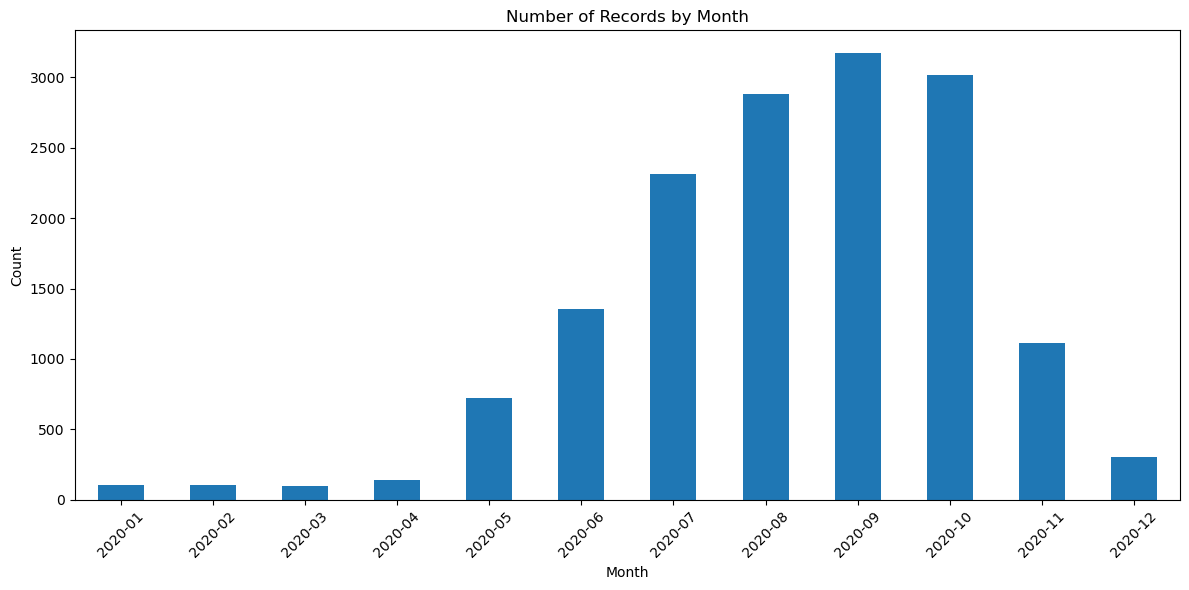

In [4]:
import seaborn as sns

import matplotlib.pyplot as plt

# Convert date columns to datetime if not already
if not pd.api.types.is_datetime64_any_dtype(df["start_date"]):
    df["start_date"] = pd.to_datetime(df["start_date"])
if not pd.api.types.is_datetime64_any_dtype(df["end_date"]):
    df["end_date"] = pd.to_datetime(df["end_date"])

# Get basic date statistics
print(f"Date range in dataset:")
print(f"Start dates: {df['start_date'].min()} to {df['start_date'].max()}")
print(f"End dates: {df['end_date'].min()} to {df['end_date'].max()}")

# Check entries with end date before 2020
before_2020 = df[df["end_date"] < "2020-01-01"]
print(f"\nEntries with end date before 2020: {len(before_2020)} ({len(before_2020)/len(df)*100:.2f}%)")

# Plot the distribution of end dates by month
plt.figure(figsize=(12, 6))
df['end_date_month'] = df['end_date'].dt.to_period('M')
date_counts = df['end_date_month'].value_counts().sort_index()
date_counts.plot(kind='bar')
plt.title('Number of Records by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

# Check data by country
country_counts = df['country'].value_counts()
print("\nRecord count by country:")
print(country_counts)

# Check presence/absence ratio
presence_counts = df['occurrenceStatus'].value_counts()
print("\nOccurrence status distribution:")
print(presence_counts)

In [5]:
import importlib as imp
import process_copernicus_data
imp.reload(process_copernicus_data)
from process_copernicus_data import extract_climate_data_to_df, aggregate_to_monthly

In [7]:
ds_merged

<xarray.Dataset> Size: 10GB
Dimensions:                  (time: 13, valid_time: 731, latitude: 390,
                              longitude: 701)
Coordinates:
  * latitude                 (latitude) float64 3kB 71.9 71.8 71.7 ... 33.1 33.0
  * longitude                (longitude) float64 6kB -25.0 -24.9 ... 44.9 45.0
  * valid_time               (valid_time) datetime64[ns] 6kB 2019-01-01 ... 2...
    number                   int64 8B 0
Dimensions without coordinates: time
Data variables:
    total_precipitation_sum  (time, valid_time, latitude, longitude) float32 10GB ...

In [6]:
import os
import pandas as pd
import xarray as xr

# Input variables (base names to search for in NetCDF files)
input_vars = [
    #"total_evaporation",
    "total_precipitation", 
    "10m_u_component_of_wind", "10m_v_component_of_wind", "2m_dewpoint_temperature", 
    #"2m_temperature",
    #"surface_net_thermal_radiation", "surface_net_solar_radiation", "surface_pressure", "skin_temperature",
    #"surface_sensible_heat_flux", "surface_latent_heat_flux", "surface_thermal_radiation_downwards",
    #"volumetric_soil_water_layer_1", #"potential_evaporation", "evaporation_from_vegetation_transpiration",
]

year = 2020  # Base year
freq = "daily"
path_dir = f"/eos/jeodpp/data/projects/ETOHA/DATA/ClimateData/Copernicus_data/europe/data/"
path_dir = f"copernicus_climate_data/europe/data/"
# Define columns for latitude, longitude, and time
lat_col = "decimalLatitude"
lon_col = "decimalLongitude"
time_col = "end_date"
time_window = "89D"  # Time window for extracting data
months_to_average = 3  # Number of months to average data over
days_per_month = 30  # Number of days in each month
time_window_avg = f"{days_per_month * months_to_average - 1}D"  # Time window for averaging data
# Ensure 'end_date' is in datetime format
df[time_col] = pd.to_datetime(df[time_col])

# Determine the years needed based on the dataframe's end_date column
first_date_needed = df[time_col].min() - pd.Timedelta(time_window_avg)
last_date_needed = df[time_col].max()

first_year_needed = first_date_needed.year
last_year_needed = last_date_needed.year

print(f"Data extraction required from {first_year_needed} to {last_year_needed}.")

# Iterate over each base climate variable name
for var in input_vars:
    print(f"\nProcessing base variable: {var}")

    # List to store datasets for merging
    datasets = []

    # Load each required year's data
    for yr in range(first_year_needed, last_year_needed + 1):
        if var in [
        "10m_u_component_of_wind", "10m_v_component_of_wind", "2m_dewpoint_temperature", "2m_temperature",
        "surface_net_thermal_radiation", "surface_net_solar_radiation", "surface_pressure", "skin_temperature",
        "surface_sensible_heat_flux", "surface_latent_heat_flux", "surface_thermal_radiation_downwards",
        "volumetric_soil_water_layer_1"]:
            input_file = f"{path_dir}{yr}/{var}_{freq}_stats_{yr}.nc"
        else:
            input_file = f"{path_dir}{yr}/{var}_{freq}_cum_{yr}.nc"


        if os.path.exists(input_file):
            print(f"Loading dataset: {input_file}")
            ds = xr.open_dataset(input_file)  # You can add chunking if needed
            datasets.append(ds)
        else:
            print(f"Warning: File {input_file} does not exist. Skipping...")

    # Merge all loaded datasets for this variable
    if datasets:
        ds_merged = xr.concat(datasets, dim="time")
        print(f"Merged {len(datasets)} datasets for {var}.")

        # Get all available variable names inside the NetCDF file
        available_vars = list(ds_merged.data_vars.keys())
        print(f"Variables available in dataset: {available_vars}")

        # Iterate over all available variables inside this dataset
        for climate_var in available_vars:
            print(f"Extracted data for: {climate_var} -- monthly average")            
            df = extract_climate_data_to_df(
                df, ds_merged, climate_var, lat_col=lat_col, lon_col=lon_col, time_col=time_col, time_window=time_window_avg
            )
            df[climate_var+"_monthly"] = df[climate_var].apply(lambda x: aggregate_to_monthly(x, num_months=months_to_average))


            print(f"Extracted data for: {climate_var} daily")
            # Call the function to extract climate data for the DataFrame
            df = extract_climate_data_to_df(
                df, ds_merged, climate_var, lat_col=lat_col, lon_col=lon_col, time_col=time_col, time_window=time_window
            )
    else:
        print(f"No datasets available for {var}. Skipping extraction.")



Data extraction required from 2019 to 2020.

Processing base variable: total_precipitation
Loading dataset: copernicus_climate_data/europe/data/2019/total_precipitation_daily_cum_2019.nc
Loading dataset: copernicus_climate_data/europe/data/2020/total_precipitation_daily_cum_2020.nc
Merged 2 datasets for total_precipitation.
Variables available in dataset: ['total_precipitation_sum']
Extracted data for: total_precipitation_sum -- monthly average


Extracting Climate Data:   0%|          | 0/15327 [00:00<?, ?it/s]


TypeError: 'str' object cannot be interpreted as an integer

In [8]:
df.to_csv("albopictus_with_climate_3m.csv")
df.to_pickle("albopictus_with_climate_3m.pkl")

In [9]:
df.columns

Index(['id', 'type', 'language', 'license', 'institutionID', 'datasetID',
       'institutionCode', 'datasetName', 'ownerInstitutionCode',
       'basisOfRecord', 'dynamicProperties', 'occurrenceID', 'individualCount',
       'lifeStage', 'establishmentMeans', 'occurrenceStatus', 'eventID',
       'parentEventID', 'eventDate', 'year', 'verbatimEventDate', 'habitat',
       'samplingProtocol', 'samplingEffort', 'locationID', 'continent',
       'country', 'countryCode', 'stateProvince', 'municipality', 'locality',
       'minimumElevationInMeters', 'maximumElevationInMeters',
       'verbatimElevation', 'decimalLatitude', 'decimalLongitude',
       'verbatimCoordinates', 'verbatimLatitude', 'verbatimLongitude',
       'verbatimCoordinateSystem', 'identificationQualifier',
       'identificationRemarks', 'taxonID', 'scientificName', 'kingdom',
       'phylum', 'class', 'order', 'family', 'genus', 'subgenus',
       'specificEpithet', 'taxonRank', 'scientificNameAuthorship',
       'verna